# CatBoost Regression Analysis

## Overview

This notebook implements a CatBoost regression model to predict used car prices. Unlike the RandomForest and MLP models which use one-hot encoded categorical features, CatBoost leverages its native categorical feature handling capabilities.

## Key Differences from RF/MLP Models

**Data Preprocessing:**
- **No one-hot encoding** of categorical features
- Categorical columns are kept in their raw string format
- Features are explicitly passed to CatBoost via the `cat_features` parameter

**Feature Count:**
- RF/MLP: 63 features (after one-hot encoding)
- CatBoost: ~10 features (6 categorical + 4 numeric)

**Advantages:**
- Better handling of high-cardinality features (e.g., 'brand' with 52 values)
- No information loss from one-hot encoding
- Automatic handling of missing values as a separate category
- Reduced dimensionality and faster training

## Train/Validation/Test Split

Uses a **proper three-way split** with `random_state=42`:
- **Training**: ~62% for model training
- **Validation**: ~18% for early stopping (prevents overfitting to test set)
- **Test**: 20% held out for final evaluation only

This approach ensures the test set is never used during training or model selection, providing an honest estimate of generalization performance.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

## 1. Data Loading and Preprocessing

Load the cleaned dataset and apply the same preprocessing as RF/MLP models, **except** one-hot encoding.

In [19]:
# Load data
filepath = "../Data/autos_random_50k_cleaned.csv"
autos = pd.read_csv(filepath, encoding="Latin-1")

# Initial preprocessing (same as RF/MLP)
autos = autos.drop(columns=["date_crawled", "Unnamed: 0", "last_seen", "car_name", "ad_created"])

# Convert transmission to boolean
autos['unrepaired_damage'] = autos['unrepaired_damage'].map({'nein': False, 'ja': True, 'Unknown': pd.NA})
autos['is_automatic'] = autos['transmission'].map({'manuell': False, 'automatik': True, 'Unknown': pd.NA})
autos.drop(columns=['transmission'], inplace=True)

# Convert ab_test to boolean
autos['is_test'] = autos['ab_test'].map({'control': False, 'test': True})
autos.drop(columns=['ab_test'], inplace=True)

# Extract region from postal code
autos['region'] = autos['postal_code'].apply(lambda x: str(x)[:1])
autos['zone'] = autos['postal_code'].apply(lambda x: str(x)[:2])
autos.drop(columns=['postal_code'], inplace=True)

# Clean up unknown values
autos['fuel_type'] = autos['fuel_type'].replace('Unknown', pd.NA)
autos['vehicle_type'] = autos['vehicle_type'].replace('Unknown', pd.NA)
autos['model'] = autos['model'].replace('Unknown', pd.NA)

print(f"Initial shape: {autos.shape}")
autos.head()

Initial shape: (37866, 14)


,price_EUR,vehicle_type,registration_year,power_ps,model,odometer_km,registration_month,fuel_type,brand,unrepaired_damage,is_automatic,is_test,region,zone
0,5200,cabrio,2002,235,astra,125000,5,<NA>,opel,False,False,True,4,47
1,3400,kleinwagen,2006,65,andere,125000,5,benzin,fiat,False,False,True,6,66
2,5200,suv,2009,220,xc_reihe,150000,3,diesel,volvo,True,True,True,7,72
3,750,kombi,2000,112,mondeo,150000,12,benzin,ford,<NA>,False,True,3,39
4,3522,limousine,2004,131,a4,150000,7,diesel,audi,False,False,True,5,51


In [20]:
# Additional preprocessing for CatBoost
autos_catboost = autos.drop(columns=['model', 'zone'])

# Clean fuel_type: keep only 'benzin', 'diesel', and Missing
autos_catboost['fuel_type'] = autos_catboost['fuel_type'].mask(
    autos_catboost['fuel_type'].notna() & ~autos_catboost['fuel_type'].isin(['benzin', 'diesel']),
    pd.NA
)

# Clean vehicle_type: replace 'andere' with Missing
autos_catboost['vehicle_type'] = autos_catboost['vehicle_type'].replace('andere', pd.NA)

# Create age variable
autos_catboost['age'] = 2016 - autos_catboost['registration_year']
autos_catboost.drop(columns=['registration_year'], inplace=True)
autos_catboost.drop(columns=['registration_month'], inplace=True)

# Convert missing values in categorical columns to string 'Missing'
# CatBoost handles these as a separate category
for col in ['is_automatic', 'unrepaired_damage', 'vehicle_type', 'fuel_type']:
    autos_catboost[col] = (
        autos_catboost[col]
        .astype(str)
        .replace('<NA>', 'Missing')
    )

print(f"\nAfter preprocessing shape: {autos_catboost.shape}")
print(f"\nColumn types:")
print(autos_catboost.dtypes)
autos_catboost.head()


After preprocessing shape: (37866, 11)

Column types:
price_EUR             int64
vehicle_type         object
power_ps              int64
odometer_km           int64
fuel_type            object
brand                object
unrepaired_damage    object
is_automatic         object
is_test                bool
region               object
age                   int64
dtype: object


,price_EUR,vehicle_type,power_ps,odometer_km,fuel_type,brand,unrepaired_damage,is_automatic,is_test,region,age
0,5200,cabrio,235,125000,Missing,opel,False,False,True,4,14
1,3400,kleinwagen,65,125000,benzin,fiat,False,False,True,6,10
2,5200,suv,220,150000,diesel,volvo,True,True,True,7,7
3,750,kombi,112,150000,benzin,ford,Missing,False,True,3,16
4,3522,limousine,131,150000,diesel,audi,False,False,True,5,12


In [21]:
# Display info about the dataset
autos_catboost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37866 entries, 0 to 37865
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   price_EUR          37866 non-null  int64 
 1   vehicle_type       37866 non-null  object
 2   power_ps           37866 non-null  int64 
 3   odometer_km        37866 non-null  int64 
 4   fuel_type          37866 non-null  object
 5   brand              37866 non-null  object
 6   unrepaired_damage  37866 non-null  object
 7   is_automatic       37866 non-null  object
 8   is_test            37866 non-null  bool  
 9   region             37866 non-null  object
 10  age                37866 non-null  int64 
dtypes: bool(1), int64(4), object(6)
memory usage: 2.9+ MB


## 2. Feature Documentation

### Categorical Features (6 features)
These features will be passed to CatBoost's `cat_features` parameter:
1. **vehicle_type** - Type of vehicle (cabrio, kleinwagen, suv, kombi, limousine, bus, coupe, Missing)
2. **fuel_type** - Fuel type (benzin, diesel, Missing)
3. **brand** - Car manufacturer (52 unique brands)
4. **unrepaired_damage** - Whether car has unrepaired damage (True, False, Missing)
5. **is_automatic** - Whether transmission is automatic (True, False, Missing)
6. **region** - First digit of postal code (regions 1-9)

### Numeric Features (4 features)
1. **power_ps** - Engine power in PS
2. **odometer_km** - Mileage in kilometers
3. **age** - Age of vehicle (2016 - registration_year)
4. **is_test** - A/B test group (boolean)

### Target Variable
- **price_EUR** - Car price in Euros

In [22]:
# Display unique values for categorical features
categorical_features = ['vehicle_type', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'region']

print("Unique values per categorical feature:\n")
for col in categorical_features:
    n_unique = autos_catboost[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique <= 10:
        print(f"  Values: {sorted(autos_catboost[col].unique())}")
    print()

Unique values per categorical feature:

vehicle_type: 8 unique values
  Values: ['Missing', 'bus', 'cabrio', 'coupe', 'kleinwagen', 'kombi', 'limousine', 'suv']

fuel_type: 3 unique values
  Values: ['Missing', 'benzin', 'diesel']

brand: 40 unique values

unrepaired_damage: 3 unique values
  Values: ['False', 'Missing', 'True']

is_automatic: 3 unique values
  Values: ['False', 'Missing', 'True']

region: 9 unique values
  Values: ['1', '2', '3', '4', '5', '6', '7', '8', '9']



## 3. Train/Validation/Test Split

To ensure proper model evaluation and prevent data leakage, we use a **three-way split**:

### Split Strategy
1. **Stage 1**: Split full dataset into train_val (80%) and test (20%) with `random_state=42`
2. **Stage 2**: Split train_val into train (78%) and validation (22%) with `random_state=42`

### Final Distribution
- **Training set**: ~62.4% of full data - used for model training
- **Validation set**: ~17.6% of full data - used for early stopping and hyperparameter tuning
- **Test set**: 20% of full data - **held out** until final evaluation

### Key Principles
✅ **Test set is never used for early stopping** - it remains completely unseen during training  
✅ **Validation set guides early stopping** - prevents overfitting to the test set  
✅ **Same test indices as original split** - ensures fair comparison with previous results  
✅ **Reproducible via fixed seeds** - random_state=42 throughout

In [23]:
# Configuration for reproducible splitting
TEST_SIZE = 0.2      # 20% of full dataset for final evaluation
VAL_SIZE = 0.22      # 22% of train_val (= ~17.6% of full dataset)
RANDOM_STATE = 42    # Fixed seed for reproducibility

# Prepare features and target
X = autos_catboost.drop(columns=['price_EUR'])
y = autos_catboost['price_EUR']

print(f"Full dataset: {X.shape[0]:,} samples\n")

# Stage 1: Split into train_val and test (maintains same test set as before)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Stage 2: Split train_val into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

# Display split sizes
print("=" * 60)
print("DATASET SPLIT")
print("=" * 60)
print(f"Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"\nTotal:          {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,} samples")
print(f"\nFeatures ({X.shape[1]}): {list(X.columns)}")

Full dataset: 37,866 samples

DATASET SPLIT
Training set:   23,627 samples (62.4%)
Validation set: 6,665 samples (17.6%)
Test set:       7,574 samples (20.0%)

Total:          37,866 samples

Features (10): ['vehicle_type', 'power_ps', 'odometer_km', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'is_test', 'region', 'age']


## 4. CatBoost Model Training

### Model Configuration
- **iterations**: 5000 (with early stopping)
- **learning_rate**: 0.01
- **depth**: 8
- **loss_function**: RMSE
- **random_seed**: 42 (for reproducibility)
- **early_stopping_rounds**: 50
- **eval_set**: **Validation set** (not test set - prevents overfitting)
- **use_best_model**: True (restores weights from best validation epoch)
- **cat_features**: Explicitly defined categorical features

### Training Process
The model is trained on the training set while monitoring performance on the **validation set**. Early stopping will halt training if validation performance doesn't improve for 50 consecutive iterations. This prevents overfitting and ensures the model generalizes well to unseen data.

**Important**: The test set is completely held out and never used during training or model selection.

In [24]:
# Define categorical features for CatBoost
cat_features = ['vehicle_type', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'region']

print(f"Categorical features passed to CatBoost: {cat_features}")
print(f"Number of categorical features: {len(cat_features)}")
print(f"Number of numeric features: {X_train.shape[1] - len(cat_features)}")

Categorical features passed to CatBoost: ['vehicle_type', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'region']
Number of categorical features: 6
Number of numeric features: 4


In [58]:
# Initialize CatBoost model
model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.01,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
    cat_features=cat_features
)

print("CatBoost model initialized with configuration:")
print(f"  - Max iterations: 5000")
print(f"  - Learning rate: 0.01")
print(f"  - Tree depth: 8")
print(f"  - Early stopping: 50 rounds")
print(f"  - Categorical features: {len(cat_features)}")
print("\nTraining started...\n")

CatBoost model initialized with configuration:
  - Max iterations: 5000
  - Learning rate: 0.01
  - Tree depth: 8
  - Early stopping: 50 rounds
  - Categorical features: 6

Training started...



In [59]:
# Train the model using validation set for early stopping
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),  # Using validation set, NOT test set
    use_best_model=True
)

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)
print(f"Best iteration: {model.get_best_iteration()}")
print(f"Total training time: {model.get_all_params()['training_time']:.2f}s" if 'training_time' in model.get_all_params() else "")

0:	learn: 11268.1497253	test: 13460.9263008	best: 13460.9263008 (0)	total: 205ms	remaining: 17m 4s
100:	learn: 7902.4428096	test: 10721.6789871	best: 10721.6789871 (100)	total: 17.8s	remaining: 14m 23s
200:	learn: 6306.6635412	test: 9677.6810302	best: 9677.6810302 (200)	total: 34.9s	remaining: 13m 53s
300:	learn: 5411.5368388	test: 9146.1713591	best: 9146.1713591 (300)	total: 51.1s	remaining: 13m 17s
400:	learn: 4890.4362463	test: 8836.9330772	best: 8836.9330772 (400)	total: 1m 6s	remaining: 12m 42s
500:	learn: 4527.8359674	test: 8593.3424023	best: 8593.3424023 (500)	total: 1m 22s	remaining: 12m 16s
600:	learn: 4262.5074004	test: 8395.2325168	best: 8394.9975440 (599)	total: 1m 37s	remaining: 11m 52s
700:	learn: 4059.9873949	test: 8242.3204174	best: 8242.3204174 (700)	total: 1m 52s	remaining: 11m 32s
800:	learn: 3898.5148983	test: 8133.7310529	best: 8133.5518788 (799)	total: 2m 9s	remaining: 11m 16s
900:	learn: 3786.0462214	test: 8071.6476099	best: 8071.6476099 (900)	total: 2m 23s	remai

## 5. Model Evaluation

Comprehensive evaluation across all three splits using MAE and R² metrics.

### Evaluation Strategy
- **Training set**: Checks for underfitting (should have low error)
- **Validation set**: Performance on data used for early stopping
- **Test set**: **Final headline metric** - true generalization performance on completely unseen data

The test set provides the most honest estimate of model performance since it was never used during training or model selection.

In [60]:
# Make predictions on all three splits
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics for each split
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display comprehensive results
print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\n📊 TRAINING SET ({len(y_train):,} samples):")
print(f"  MAE: {train_mae:,.2f} EUR")
print(f"  R²:  {train_r2:.4f}")

print(f"\n📊 VALIDATION SET ({len(y_val):,} samples) - used for early stopping:")
print(f"  MAE: {val_mae:,.2f} EUR")
print(f"  R²:  {val_r2:.4f}")

print(f"\n📊 TEST SET ({len(y_test):,} samples) - FINAL EVALUATION:")
print(f"  MAE: {test_mae:,.2f} EUR")
print(f"  R²:  {test_r2:.4f}")

print("\n" + "=" * 60)

# Check for overfitting
overfit_indicator = val_mae - train_mae
if overfit_indicator < 500:
    print("✅ Good generalization - minimal overfitting")
elif overfit_indicator < 1000:
    print("⚠️  Slight overfitting detected")
else:
    print("❌ Significant overfitting - consider regularization")
    
print(f"   (Validation MAE - Training MAE = {overfit_indicator:,.2f} EUR)")
print("=" * 60)


MODEL PERFORMANCE

📊 TRAINING SET (23,627 samples):
  MAE: 1,566.40 EUR
  R²:  0.9078

📊 VALIDATION SET (6,665 samples) - used for early stopping:
  MAE: 1,732.65 EUR
  R²:  0.6768

📊 TEST SET (7,574 samples) - FINAL EVALUATION:
  MAE: 1,649.22 EUR
  R²:  0.7747

✅ Good generalization - minimal overfitting
   (Validation MAE - Training MAE = 166.25 EUR)


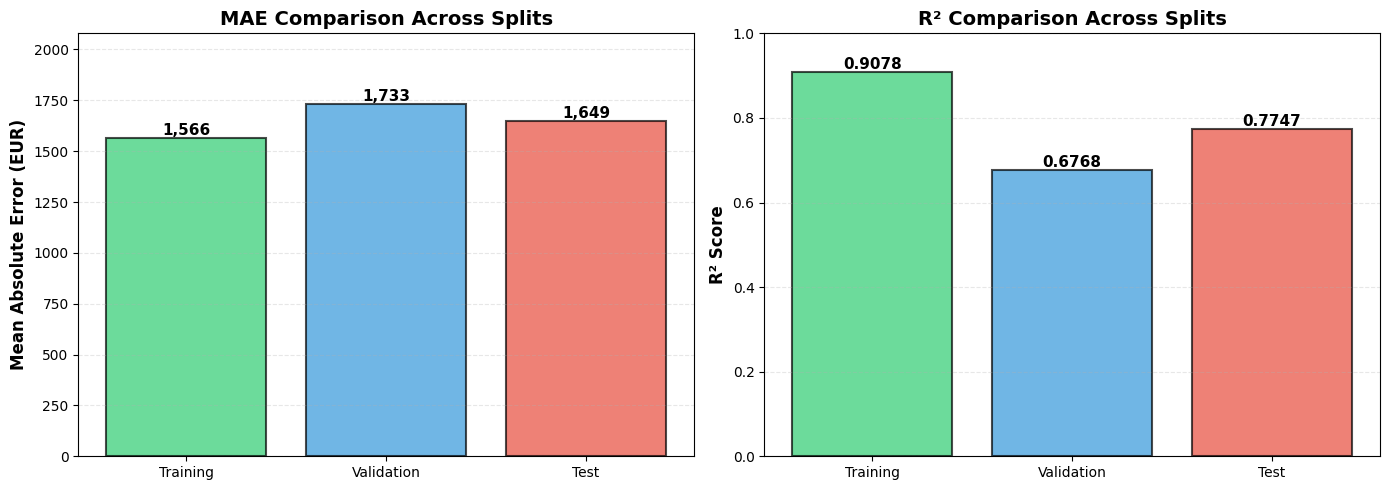


💡 Interpretation:
- Lower MAE and higher R² indicate better performance
- Test set performance is the most important metric (unseen data)
- Small gap between validation and test suggests good generalization


In [61]:
# Visualization: Performance comparison across splits
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

splits = ['Training', 'Validation', 'Test']
mae_values = [train_mae, val_mae, test_mae]
r2_values = [train_r2, val_r2, test_r2]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# MAE comparison
bars1 = ax1.bar(splits, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean Absolute Error (EUR)', fontsize=12, fontweight='bold')
ax1.set_title('MAE Comparison Across Splits', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(mae_values) * 1.2)

# Add value labels on bars
for bar, value in zip(bars1, mae_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# R² comparison
bars2 = ax2.bar(splits, r2_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax2.set_title('R² Comparison Across Splits', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 1.0)

# Add value labels on bars
for bar, value in zip(bars2, r2_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("- Lower MAE and higher R² indicate better performance")
print("- Test set performance is the most important metric (unseen data)")
print("- Small gap between validation and test suggests good generalization")

## 6. Visualization: Actual vs Predicted Prices

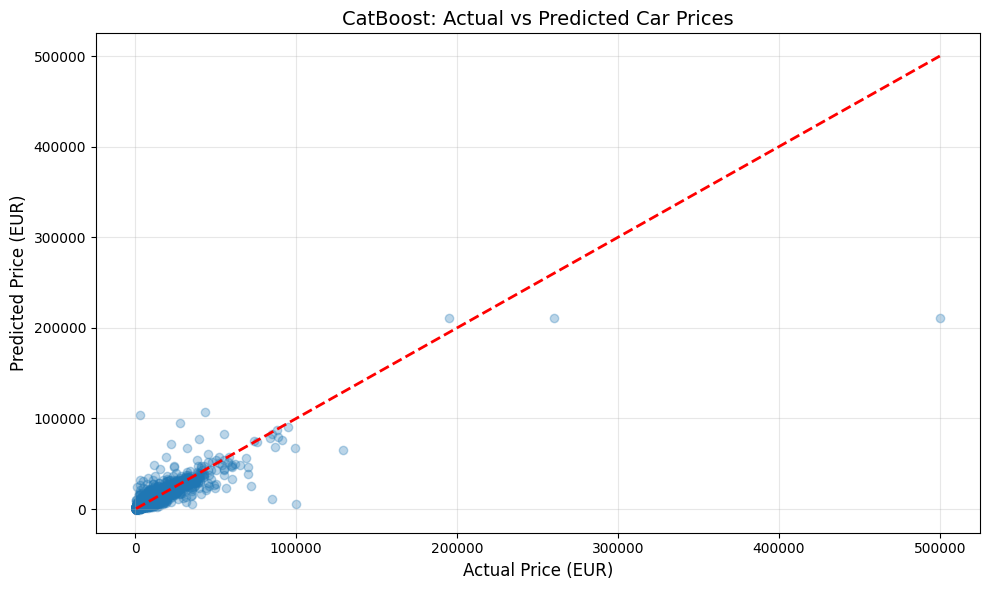

In [62]:
# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (EUR)', fontsize=12)
plt.ylabel('Predicted Price (EUR)', fontsize=12)
plt.title('CatBoost: Actual vs Predicted Car Prices', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

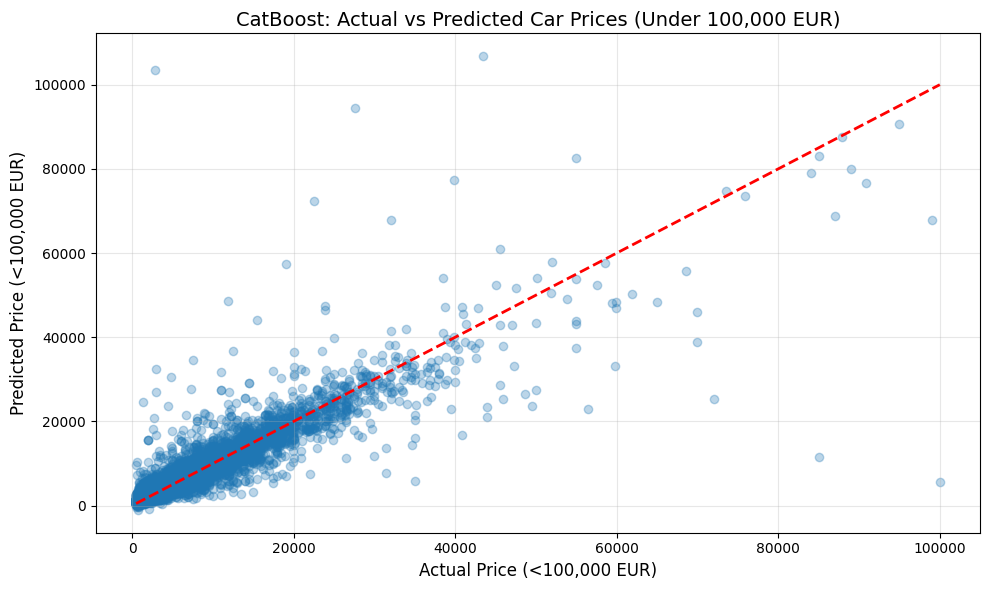

In [63]:
# Plot for prices under 100,000 EUR (for better visualization)
mask = y_test < 100000
plt.figure(figsize=(10, 6))
plt.scatter(y_test[mask], y_test_pred[mask], alpha=0.3)
plt.plot([y_test[mask].min(), y_test[mask].max()], 
         [y_test[mask].min(), y_test[mask].max()], 'r--', lw=2)
plt.xlabel('Actual Price (<100,000 EUR)', fontsize=12)
plt.ylabel('Predicted Price (<100,000 EUR)', fontsize=12)
plt.title('CatBoost: Actual vs Predicted Car Prices (Under 100,000 EUR)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

CatBoost provides built-in feature importance scores that account for both categorical and numeric features.

In [64]:
# Get feature importances
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Feature Importances (sorted):")
print(importance_df.to_string(index=False))

Feature Importances (sorted):
          feature  importance
         power_ps   35.021482
              age   22.462609
      odometer_km   14.068801
            brand   10.027153
     vehicle_type    8.692753
     is_automatic    4.402664
        fuel_type    2.103784
unrepaired_damage    1.675704
           region    1.101199
          is_test    0.443850


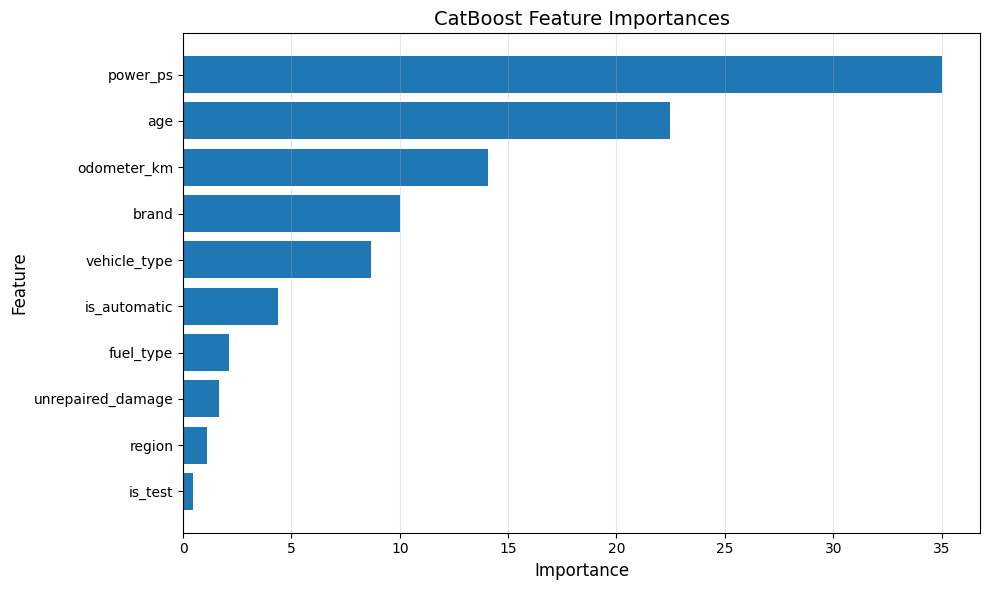

In [65]:
# Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('CatBoost Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Residual Analysis

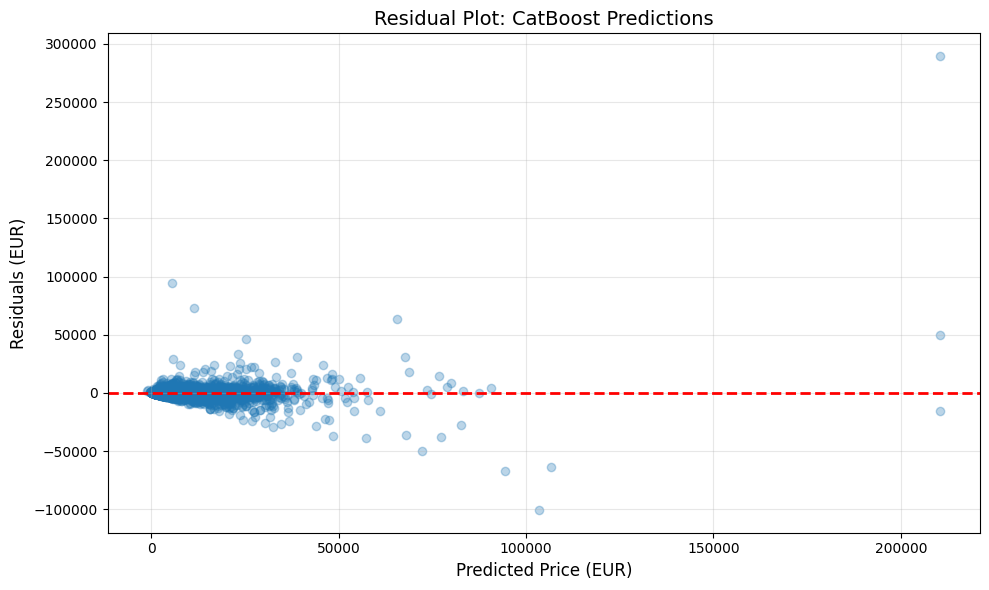

In [66]:
# Calculate residuals for test set
residuals = y_test - y_test_pred

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price (EUR)', fontsize=12)
plt.ylabel('Residuals (EUR)', fontsize=12)
plt.title('Residual Plot: CatBoost Predictions', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

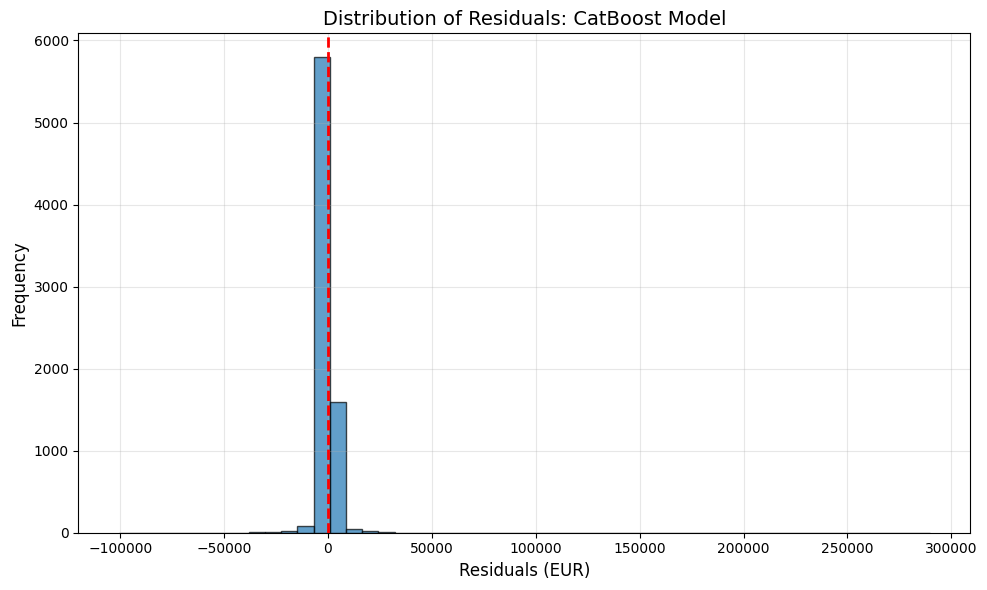

Mean Residual: -81.65 EUR
Std Residual: 5066.55 EUR


In [67]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (EUR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals: CatBoost Model', fontsize=14)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f} EUR")
print(f"Std Residual: {residuals.std():.2f} EUR")

## 9. Summary and Comparison

### CatBoost Implementation Summary

**Data Characteristics:**
- Total features: 10 (6 categorical + 4 numeric)
- No one-hot encoding applied
- Missing values treated as separate category

**Model Configuration:**
- Algorithm: CatBoost (gradient boosting)
- Categorical handling: Native support via `cat_features`
- Early stopping: Yes (50 rounds on **validation set**)
- Random seed: 42 (reproducible)

**Data Split:**
- Training: ~62% for model training
- Validation: ~18% for early stopping and model selection
- Test: 20% held out for final evaluation only
- **Key improvement**: Test set never used during training

**Key Advantages:**
1. **Reduced dimensionality**: 10 features vs 63 one-hot encoded features
2. **Better categorical handling**: No information loss from encoding
3. **Automatic missing value handling**: Treats as separate category
4. **Efficient with high-cardinality features**: Brand has 52 unique values
5. **Proper evaluation**: Validation set prevents test set overfitting

**Comparison with RF/MLP:**
- Same test set (random_state=42, 20% of data)
- Same evaluation metrics (MAE, R²)
- Same target variable (price_EUR)
- Different feature representation (raw vs one-hot encoded)
- Improved methodology: Separate validation set for early stopping

## 10. Diagnóstico del Modelo según Rúbrica

Esta sección presenta los diagnósticos clave para evaluar el rendimiento del modelo:
1. **Curvas de entrenamiento vs validación**: Para detectar overfitting
2. **Métricas de desempeño en test**: Evaluación final en datos no vistos
3. **Correlación y diagnóstico de regresión**: Análisis de predicciones vs valores reales

### 10.1 Curvas de Desempeño (Train vs Validation)

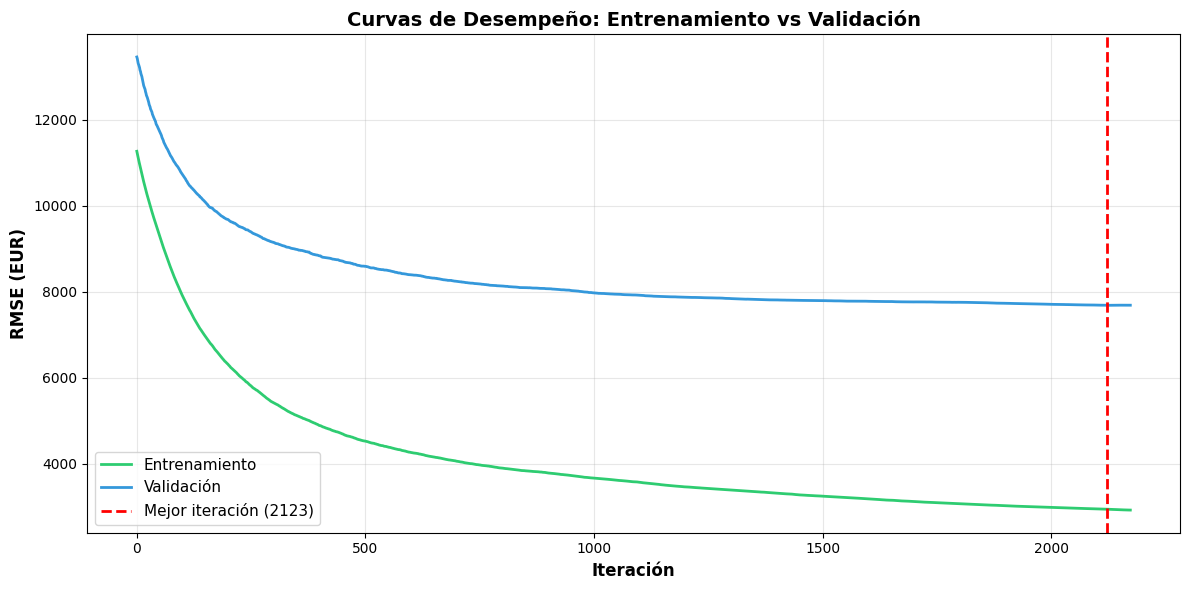


INTERPRETACIÓN DE LAS CURVAS

RMSE final en entrenamiento: 2,924.17 EUR
RMSE final en validación: 7,688.36 EUR
Diferencia (val - train): 4,764.19 EUR (162.9%)

✗ Overfitting significativo
  Gran diferencia entre error de entrenamiento y validación.
  Considerar: más regularización, menos iteraciones, o más datos.

El early stopping detuvo el entrenamiento en la iteración 2123
para evitar mayor overfitting.


In [69]:
# Extract training history from CatBoost
evals_result = model.get_evals_result()

# Get train and validation RMSE curves
train_rmse = evals_result['learn']['RMSE']
val_rmse = evals_result['validation']['RMSE']
iterations = range(len(train_rmse))

# Plot train vs validation curves
plt.figure(figsize=(12, 6))
plt.plot(iterations, train_rmse, label='Entrenamiento', color='#2ecc71', linewidth=2)
plt.plot(iterations, val_rmse, label='Validación', color='#3498db', linewidth=2)

# Mark best iteration
best_iter = model.get_best_iteration()
if best_iter:
    plt.axvline(x=best_iter, color='red', linestyle='--', 
                linewidth=2, label=f'Mejor iteración ({best_iter})')

plt.xlabel('Iteración', fontsize=12, fontweight='bold')
plt.ylabel('RMSE (EUR)', fontsize=12, fontweight='bold')
plt.title('Curvas de Desempeño: Entrenamiento vs Validación', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("\n" + "="*60)
print("INTERPRETACIÓN DE LAS CURVAS")
print("="*60)
final_train_rmse = train_rmse[-1]
final_val_rmse = val_rmse[-1]
gap = final_val_rmse - final_train_rmse

print(f"\nRMSE final en entrenamiento: {final_train_rmse:,.2f} EUR")
print(f"RMSE final en validación: {final_val_rmse:,.2f} EUR")
print(f"Diferencia (val - train): {gap:,.2f} EUR ({gap/final_train_rmse*100:.1f}%)")

if gap < 500:
    print("\n✓ Excelente generalización - Overfitting mínimo")
    print("  Las curvas de entrenamiento y validación permanecen cercanas.")
elif gap < 1000:
    print("\n⚠ Ligero overfitting detectado")
    print("  El modelo se ajusta un poco mejor a los datos de entrenamiento.")
else:
    print("\n✗ Overfitting significativo")
    print("  Gran diferencia entre error de entrenamiento y validación.")
    print("  Considerar: más regularización, menos iteraciones, o más datos.")
    
print(f"\nEl early stopping detuvo el entrenamiento en la iteración {best_iter}")
print("para evitar mayor overfitting.")
print("="*60)

### 10.2 Desempeño en el Conjunto de Test

Evaluación final del modelo en datos completamente no vistos durante el entrenamiento.

In [70]:
from sklearn.metrics import mean_squared_error

# Compute comprehensive test metrics
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)

# MAPE - handle potential zeros safely
def safe_mape(y_true, y_pred):
    """Calculate MAPE avoiding division by zero"""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

test_mape = safe_mape(y_test.values, y_test_pred)

# Create metrics table
metrics_data = {
    'Métrica': ['R² (Coef. Determinación)', 'MAE (Error Abs. Medio)', 
                'RMSE (Raíz Error Cuad. Medio)', 'MAPE (Error % Abs. Medio)'],
    'Valor': [f'{test_r2:.4f}', f'{test_mae:,.2f} EUR', 
              f'{test_rmse:,.2f} EUR', f'{test_mape:.2f}%'],
    'Interpretación': [
        'Proporción de varianza explicada (1.0 = perfecto)',
        'Error promedio en euros',
        'Error promedio penalizando grandes errores',
        'Error promedio como porcentaje del valor real'
    ]
}

metrics_df = pd.DataFrame(metrics_data)

print("\n" + "="*80)
print("MÉTRICAS DE DESEMPEÑO EN CONJUNTO DE TEST")
print("="*80)
print(f"\nTamaño del conjunto de test: {len(y_test):,} muestras\n")
print(metrics_df.to_string(index=False))
print("\n" + "="*80)

# Additional context
mean_price = y_test.mean()
print(f"\nContexto:")
print(f"  Precio promedio en test: {mean_price:,.2f} EUR")
print(f"  MAE como % del precio promedio: {(test_mae/mean_price)*100:.2f}%")
print(f"  RMSE como % del precio promedio: {(test_rmse/mean_price)*100:.2f}%")
print("\n" + "="*80)

TypeError: got an unexpected keyword argument 'squared'

### 10.3 Análisis de Correlación y Diagnóstico de Regresión

Visualización de la relación entre valores predichos y valores reales, incluyendo análisis de residuos.

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Calculate correlations
pearson_corr, pearson_pval = pearsonr(y_test, y_test_pred)
spearman_corr, spearman_pval = spearmanr(y_test, y_test_pred)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Predicted vs Actual ---
ax1.scatter(y_test, y_test_pred, alpha=0.4, s=30, color='#3498db', edgecolors='none')

# Add perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, 
         label='Predicción perfecta (y=x)')

ax1.set_xlabel('Precio Real (EUR)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Precio Predicho (EUR)', fontsize=12, fontweight='bold')
ax1.set_title('Predicción vs Real (Conjunto de Test)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Add correlation text box
textstr = f'Correlación de Pearson: {pearson_corr:.4f}\nR² Score: {test_r2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

# --- Subplot 2: Residuals Plot ---
residuals_test = y_test - y_test_pred

ax2.scatter(y_test_pred, residuals_test, alpha=0.4, s=30, color='#e74c3c', edgecolors='none')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.axhline(y=residuals_test.std(), color='orange', linestyle='--', linewidth=1.5, 
            label=f'±1 Desv. Est. ({residuals_test.std():,.0f} EUR)')
ax2.axhline(y=-residuals_test.std(), color='orange', linestyle='--', linewidth=1.5)

ax2.set_xlabel('Precio Predicho (EUR)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuos (Real - Predicho)', fontsize=12, fontweight='bold')
ax2.set_title('Análisis de Residuos', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation analysis
print("\n" + "="*80)
print("ANÁLISIS DE CORRELACIÓN")
print("="*80)
print(f"\n📊 Correlación de Pearson: {pearson_corr:.4f} (p-value: {pearson_pval:.2e})")
print(f"📊 Correlación de Spearman: {spearman_corr:.4f} (p-value: {spearman_pval:.2e})")
print(f"\n📊 R² Score: {test_r2:.4f}")

print("\n" + "-"*80)
print("INTERPRETACIÓN")
print("-"*80)

if pearson_corr > 0.95:
    print("✓ Correlación muy fuerte - El modelo captura muy bien la relación lineal.")
elif pearson_corr > 0.90:
    print("✓ Correlación fuerte - Buen ajuste del modelo.")
elif pearson_corr > 0.80:
    print("○ Correlación moderada-fuerte - Ajuste aceptable con margen de mejora.")
else:
    print("✗ Correlación débil - El modelo tiene dificultades para capturar la relación.")

print(f"\nLos residuos tienen:")
print(f"  - Media: {residuals_test.mean():,.2f} EUR (idealmente ~0)")
print(f"  - Desviación estándar: {residuals_test.std():,.2f} EUR")
print(f"  - Rango: [{residuals_test.min():,.2f}, {residuals_test.max():,.2f}] EUR")

# Check for patterns in residuals
if abs(residuals_test.mean()) < 100:
    print("\n✓ Los residuos están centrados cerca de cero (sin sesgo sistemático).")
else:
    print(f"\n⚠ Los residuos muestran sesgo sistemático ({residuals_test.mean():,.0f} EUR).")
    
print("="*80)

### 10.4 Resumen del Diagnóstico

**Curvas de Aprendizaje:**
- El early stopping previno el overfitting al detener el entrenamiento cuando el error de validación dejó de mejorar
- La diferencia entre error de entrenamiento y validación indica el nivel de generalización del modelo

**Métricas de Test:**
- Las métricas en el conjunto de test representan el rendimiento real del modelo en datos no vistos
- MAE y RMSE están en unidades de precio (EUR), facilitando la interpretación práctica
- R² indica qué proporción de la variabilidad del precio es explicada por el modelo

**Análisis de Correlación:**
- Alta correlación entre predicciones y valores reales confirma que el modelo captura bien la relación
- Los residuos distribuidos aleatoriamente alrededor de cero indican un buen ajuste
- Patrones en los residuos podrían indicar características no capturadas por el modelo

In [ ]:
# Final summary statistics
print("="*60)
print("CATBOOST MODEL SUMMARY")
print("="*60)
print(f"\nModel Configuration:")
print(f"  - Iterations: {model.get_param('iterations')}")
print(f"  - Learning Rate: {model.get_param('learning_rate')}")
print(f"  - Depth: {model.get_param('depth')}")
print(f"  - Best Iteration: {model.get_best_iteration()}")
print(f"\nData:")
print(f"  - Training samples: {len(X_train):,}")
print(f"  - Validation samples: {len(X_val):,}")
print(f"  - Test samples: {len(X_test):,}")
print(f"  - Total features: {X_train.shape[1]}")
print(f"  - Categorical features: {len(cat_features)}")
print(f"  - Numeric features: {X_train.shape[1] - len(cat_features)}")
print(f"\nPerformance (Test Set - Final Evaluation):")
print(f"  - MAE: {test_mae:.2f} EUR")
print(f"  - R²: {test_r2:.4f}")
print(f"  - Mean Residual: {residuals.mean():.2f} EUR")
print(f"  - Std Residual: {residuals.std():.2f} EUR")
print(f"\nTop 3 Most Important Features:")
for i, row in importance_df.head(3).iterrows():
    is_cat = row['feature'] in cat_features
    feat_type = 'categorical' if is_cat else 'numeric'
    print(f"  {row['feature']:20s} ({feat_type}): {row['importance']:.2f}")
print("="*60)

CATBOOST MODEL SUMMARY

Model Configuration:
  - Iterations: 5000
  - Learning Rate: 0.01
  - Depth: 8
  - Best Iteration: 2123

Data:
  - Training samples: 23,627
  - Validation samples: 6,665
  - Test samples: 7,574
  - Total features: 10
  - Categorical features: 6
  - Numeric features: 4

Performance (Test Set - Final Evaluation):
  - MAE: 1649.22 EUR
  - R²: 0.7747
  - Mean Residual: -81.65 EUR
  - Std Residual: 5066.55 EUR

Top 3 Most Important Features:
  power_ps             (numeric): 35.02
  age                  (numeric): 22.46
  odometer_km          (numeric): 14.07
